# Three ways your data can mislead you

*Quantitative Research Methods — Music*

In *Comparing populations with samples* we saw that honest random samples can lie to
you through sheer luck. This notebook is about three traps that catch researchers
**after** the data are safely collected — cases where the numbers are perfectly
correct and the *interpretation* is wrong:

1. **Correlation is not causation** — two things move together, but neither causes the other.
2. **Simpson's paradox** — a trend that is true in every subgroup reverses when you pool the data.
3. **Regression to the mean** — extreme performers drift back toward average, and it looks like your intervention worked.

As before, we simulate a world in which **we secretly know the truth**, so we can
watch the wrong conclusion emerge from correct data.

Throughout, each example is built from three kinds of cell, kept separate on purpose:
**data** cells that create the simulated world, **analysis** cells that compute the
numbers a researcher would report, and **plot** cells that only draw.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets   # interactive buttons

# One random generator with a fixed seed, so everyone gets the same "world".
# Change the seed and re-run everything for different luck — same lessons.
rng = np.random.default_rng(11)

# A consistent look for every plot in this notebook
BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#3f9b57"
INK, MUTED = "#0b0b0b", "#898781"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.size": 11, "figure.dpi": 110,
})

def fit_line(x, y):
    """Least-squares straight line through the points; returns (slope, intercept).

    np.polyfit with degree 1 fits a straight line y = slope * x + intercept.
    """
    slope, intercept = np.polyfit(x, y, 1)
    return slope, intercept

## 1. Correlation is not causation

A celebrated finding in music cognition: **musicians hear speech in noisy rooms
better than non-musicians.** Our simulated researcher measures **120 adults**:
*years of musical training*, and performance on a **speech-in-noise test** —
repeating sentences played against a babble of competing voices (% correct).

Here is the truth of our simulated world, which the researcher cannot see: a hidden
variable — **a musical childhood** — drives *both* numbers. People who grew up in
homes full of music — singing at the dinner table, records always on, games built
around sound — are far more likely to take up formal training and stay with it for
years. And that same childhood of attentive listening builds sharp everyday
hearing skills, lessons or no lessons. In our world the formal training itself adds
**nothing** — we wrote the code, so we know.

In [2]:
# ---------- data: the researcher's survey ----------
n = 120

# The hidden cause of everything: how musical each participant's childhood
# home was, scored 0 (no music at all) to 10 (music at every meal).
# Long over by the time of the study — the researcher never measured it;
# only we can see it.
musical_home = rng.uniform(0, 10, size=n)

# Years of formal musical training: people from musical homes are far more
# likely to start lessons and stay with them (~1.4 years per point), plus
# life circumstances (random noise, sd 2). .clip(min=0) forbids negative years.
training_years = (1.4 * musical_home + rng.normal(0, 2, n)).clip(min=0).round(1)

# Speech-in-noise test (% of sentences repeated correctly): a base of 40,
# plus 4.5 points per musical-home point — a childhood of attentive listening
# builds sharp everyday hearing — plus attention on the day (sd 6).
# Note what is NOT in this formula: `training_years`. Zero causal effect, by design.
hearing_score = (40 + 4.5 * musical_home + rng.normal(0, 6, n)).clip(0, 100)

# ---------- analysis: the one number the researcher reports ----------
# np.corrcoef returns a 2x2 correlation matrix; [0, 1] is r between the two variables
r_obs = np.corrcoef(training_years, hearing_score)[0, 1]

print(f"Correlation between musical training and speech-in-noise: r = {r_obs:.2f}")
print("Reminder: in this simulated world, training does NOTHING to hearing.")

Correlation between musical training and speech-in-noise: r = 0.86
Reminder: in this simulated world, training does NOTHING to hearing.


The researcher, of course, sees none of the code above — only 120 pairs of numbers.
Here is their scatter plot:

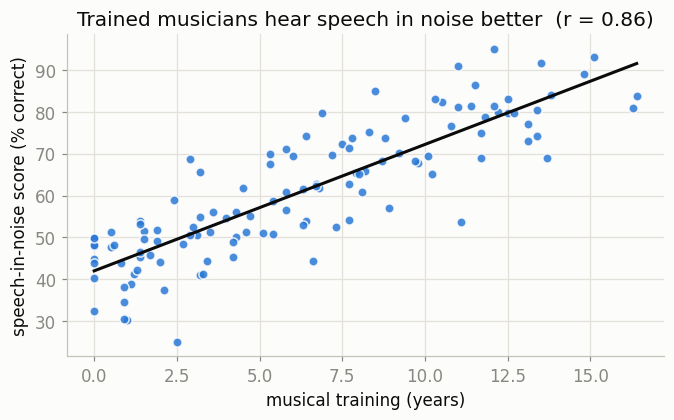

In [3]:
# ---------- plot: what the researcher sees ----------
fig, ax = plt.subplots(figsize=(7, 3.8))

# each dot is one participant
ax.plot(training_years, hearing_score, "o", color=BLUE, markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.85)

# the least-squares trend line through all 120 participants
slope, intercept = fit_line(training_years, hearing_score)
xs = np.array([training_years.min(), training_years.max()])
ax.plot(xs, slope * xs + intercept, color=INK, linewidth=2)

ax.set_xlabel("musical training (years)")
ax.set_ylabel("speech-in-noise score (% correct)")
ax.set_title(f"Trained musicians hear speech in noise better  (r = {r_obs:.2f})")
plt.show()

The correlation is strong, and it is **not** sampling luck — with 120 participants,
a correlation this size is far outside what chance produces (last notebook's
lesson). The headline writes itself:

> *"Music training rewires the ear: musicians cut through the cocktail-party din."*

The correlation is real. The *causal claim* is wrong. The pattern is produced by a
**third variable** — a *confounder* — that pushes both measurements at once: a
musical childhood steers people into years of training, and the same childhood
wins the hearing test. Because this is our simulated world, we can do what real
researchers cannot: look directly at the hidden variable. Let's split the 120
participants into three bands of childhood musicality and re-compute the
correlation *within* each band.

In [4]:
# ---------- analysis: the correlation inside each childhood band ----------
# Each entry is (label, mask, colour); the mask is a boolean array that
# selects that band's participants from the arrays above.
bands = [("least musical homes (0–3.3)", (musical_home < 3.3), BLUE),
         ("middling homes (3.3–6.7)",    (musical_home >= 3.3) & (musical_home < 6.7), GREEN),
         ("most musical homes (6.7–10)", (musical_home >= 6.7), ORANGE)]

for label, mask, color in bands:
    r_band = np.corrcoef(training_years[mask], hearing_score[mask])[0, 1]
    print(f"{label}:  {mask.sum():3d} participants,  r = {r_band:+.2f}")

print(f"\nAll 120 participants pooled:  r = {r_obs:+.2f}")

least musical homes (0–3.3):   51 participants,  r = +0.43
middling homes (3.3–6.7):   34 participants,  r = +0.33
most musical homes (6.7–10):   35 participants,  r = +0.44

All 120 participants pooled:  r = +0.86


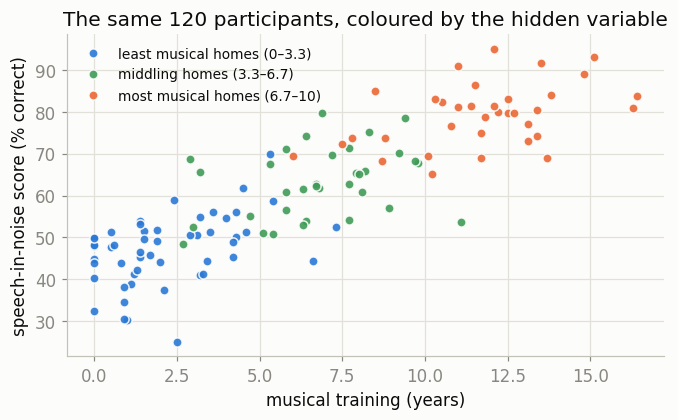

In [5]:
# ---------- plot: the same 120 participants, coloured by the hidden variable ----------
fig, ax = plt.subplots(figsize=(7, 3.8))

for label, mask, color in bands:
    ax.plot(training_years[mask], hearing_score[mask], "o", color=color, markersize=6,
            markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.9, label=label)

ax.set_xlabel("musical training (years)")
ax.set_ylabel("speech-in-noise score (% correct)")
ax.set_title("The same 120 participants, coloured by the hidden variable")
ax.legend(frameon=False, fontsize=9)
plt.show()

The picture falls apart into three clouds. **Within** each band the correlation
shrinks dramatically — most of the original r = 0.8 was childhood in disguise:
participants from the most musical homes sit in the top-right, those from the
quietest homes in the bottom-left, and the line through the pooled cloud connects
*childhoods*, not *causes*. This trap has a name in the methods literature:
**self-selection**. Nobody assigned our 120 people to be musicians — they (and
their families) sorted themselves, and whatever sorted them comes bundled into
every comparison of musicians with non-musicians.

In real research the confounder is barely observable — you can ask adults about
their childhood homes, but memory is selective, and no questionnaire captures a
whole childhood of listening. And controlling for the confounders you *thought of*
never rules out the ones you didn't. So how do you ever establish causation? You
**intervene** — which is why music cognition runs *longitudinal training studies*.
Recruit volunteers and let chance decide the training: each participant is assigned
**by lottery** between 0 and 100 hours of instrumental lessons over the next year,
and then everyone sits the hearing test again:

In [6]:
# ---------- data: the randomised training study ----------
# Each participant is assigned a RANDOM amount of training, 0 to 100 hours
# over one year. Randomisation is the whole point: the assigned hours are
# connected to nothing about the person — least of all their childhood.
assigned_hours = rng.uniform(0, 100, size=n).round()

# The hearing test a year later: exactly the same formula as before —
# childhood home + attention on the day. The assigned training does not
# appear in it, because in truth training does nothing to hearing here.
hearing_after = (40 + 4.5 * musical_home + rng.normal(0, 6, n)).clip(0, 100)

# ---------- analysis: observational vs experimental correlation ----------
r_exp = np.corrcoef(assigned_hours, hearing_after)[0, 1]

print(f"Observational survey:  r = {r_obs:+.2f}   (training people chose themselves)")
print(f"Training study:        r = {r_exp:+.2f}   (training assigned by lottery)")

Observational survey:  r = +0.86   (training people chose themselves)
Training study:        r = -0.08   (training assigned by lottery)


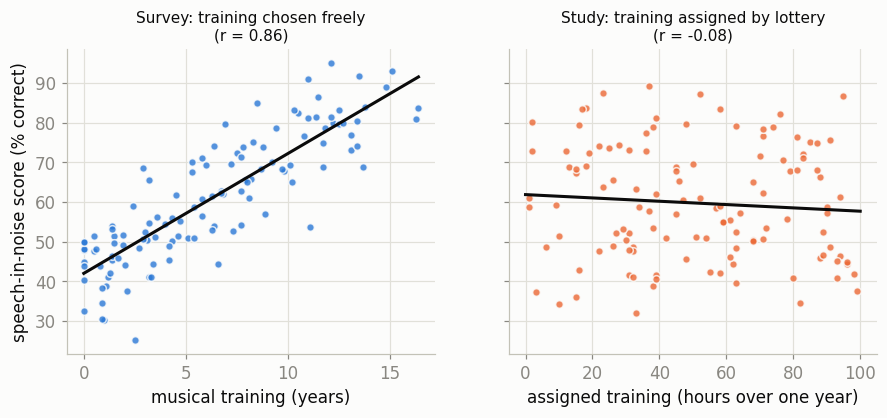

In [7]:
# ---------- plot: observation and experiment side by side ----------
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), sharey=True)

# left panel: the original survey
axes[0].plot(training_years, hearing_score, "o", color=BLUE, markersize=5,
             markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.8)
slope, intercept = fit_line(training_years, hearing_score)
xs = np.array([training_years.min(), training_years.max()])
axes[0].plot(xs, slope * xs + intercept, color=INK, linewidth=2)
axes[0].set_title(f"Survey: training chosen freely\n(r = {r_obs:.2f})", fontsize=10)
axes[0].set_xlabel("musical training (years)")
axes[0].set_ylabel("speech-in-noise score (% correct)")

# right panel: the training study — the trend line is now flat
axes[1].plot(assigned_hours, hearing_after, "o", color=ORANGE, markersize=5,
             markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.8)
slope, intercept = fit_line(assigned_hours, hearing_after)
xs = np.array([0, 100])
axes[1].plot(xs, slope * xs + intercept, color=INK, linewidth=2)
axes[1].set_title(f"Study: training assigned by lottery\n(r = {r_exp:.2f})",
                  fontsize=10)
axes[1].set_xlabel("assigned training (hours over one year)")

plt.show()

A lottery-assigned year of training does nothing to the hearing scores — the flat
line on the right is the true causal effect (zero), finally visible.

Three lessons worth keeping:

1. **Correlation is symmetric; causation is not.** In our world neither variable
   causes the other — both are echoes of a childhood long past. From the scatter
   alone you could equally believe that training sharpens hearing; the plot is
   identical to the one a real training effect would produce, and cannot tell the
   two worlds apart.
2. **Correlation is still useful — for *prediction*.** Knowing someone has twelve
   years of training genuinely helps you *guess* their speech-in-noise score. It
   just doesn't tell you what a year of lessons would *do* for your grandmother's
   hearing.
3. **Randomisation is the causal microscope.** By assigning training at random, the
   study cuts every possible thread between "training" and everything that came
   before it — including all the confounders nobody thought to measure, and the
   ones no questionnaire can fully capture.

This is a live controversy in real music cognition, not a textbook fable.
Cross-sectional studies keep finding that musicians outperform non-musicians on
speech-in-noise and other auditory tasks; critics keep pointing out that musicians
are **self-selected** — nobody randomised them into music, so everything that was
already different about them before their first lesson rides along in every
comparison. The randomised training studies that exist find effects that are
smaller and less consistent than the correlational literature suggests, and the
argument continues. When you read "musicians have better X", the first question is
always: *who became a musician — and what else came with that?*

## 2. Simpson's paradox — when pooling reverses the truth

New research question: **does practice improve jury scores?** We survey the whole
conservatorium — every student's weekly practice hours and jury score.

The truth of our simulated world: within *every* year level, **each extra hour of
weekly practice really adds +1.2 points**. Practice genuinely works, for everyone.
But the year levels differ: first-years are still building technique — long hours on
fundamentals, lower scores — while third-years carry years of accumulated skill:
higher scores from fewer (more efficient) hours.

In [8]:
# ---------- data: three year-level cohorts ----------
# Each cohort: (name, mean weekly practice hours, score baseline, plot colour).
# Practice DECREASES with seniority; the score baseline INCREASES with it —
# that opposite movement is what will produce the paradox.
cohorts = [("1st year", 22, 40, BLUE),
           ("2nd year", 16, 55, GREEN),
           ("3rd year", 10, 70, ORANGE)]
n_cohort = 40

# Within EVERY cohort, one extra hour of practice truly adds this many points:
TRUE_SLOPE = 1.2

practice, score, year = [], [], []
for name, mean_hours, base, _ in cohorts:
    # hours: spread around the cohort's mean (sd 3); nobody below 2 h/week
    hours = rng.normal(mean_hours, 3, n_cohort).clip(min=2)
    practice.append(hours)
    # score: cohort baseline + the true practice effect + luck on the day (sd 4)
    score.append((base + TRUE_SLOPE * hours + rng.normal(0, 4, n_cohort)).clip(max=100))
    year += [name] * n_cohort

# Stack the three cohorts into flat arrays — the researcher receives ONE
# spreadsheet of 120 students, with no year-level column in sight
practice, score, year = np.concatenate(practice), np.concatenate(score), np.array(year)

# ---------- analysis: the pooled trend the researcher reports ----------
r_pooled = np.corrcoef(practice, score)[0, 1]
slope_pooled, int_pooled = fit_line(practice, score)

print(f"Pooled trend: {slope_pooled:+.2f} points per extra hour of practice "
      f"(r = {r_pooled:.2f})")
print(f"Reminder: we BUILT this world so that practice adds "
      f"+{TRUE_SLOPE} points/hour for everyone.")

Pooled trend: -0.57 points per extra hour of practice (r = -0.43)
Reminder: we BUILT this world so that practice adds +1.2 points/hour for everyone.


One hundred and twenty students, one scatter plot:

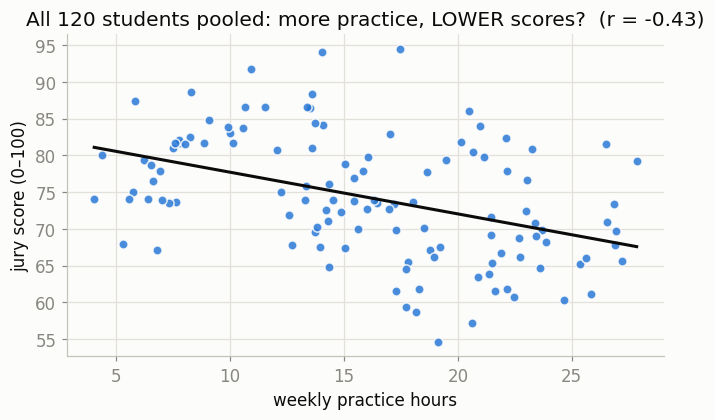

In [9]:
# ---------- plot: all students pooled, as the researcher sees them ----------
fig, ax = plt.subplots(figsize=(7, 3.8))

ax.plot(practice, score, "o", color=BLUE, markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.85)

# the pooled least-squares trend line — it slopes DOWN
xs = np.array([practice.min(), practice.max()])
ax.plot(xs, slope_pooled * xs + int_pooled, color=INK, linewidth=2)

ax.set_xlabel("weekly practice hours")
ax.set_ylabel("jury score (0–100)")
ax.set_title(f"All 120 students pooled: more practice, LOWER scores?  (r = {r_pooled:.2f})")
plt.show()

The pooled data say practice makes you *worse* — the exact opposite of the truth we
programmed in. Before reading on: can you see why?

Run the next cell and click **"reveal the year levels"** to toggle between the
researcher's view and the truth.

In [10]:
# ---------- interactive: toggle between the pooled view and the truth ----------
revealed = {"on": False}
reveal_button = widgets.Button(description="🎓  reveal the year levels",
                               layout=widgets.Layout(width="240px"))
reveal_panel = widgets.Output()

def redraw_reveal():
    with reveal_panel:
        reveal_panel.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 3.8))
        xs = np.array([practice.min(), practice.max()])
        if not revealed["on"]:
            # the researcher's view: one anonymous cloud, one falling trend line
            ax.plot(practice, score, "o", color=BLUE, markersize=6,
                    markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.85)
            ax.plot(xs, slope_pooled * xs + int_pooled, color=INK, linewidth=2)
            ax.set_title(f"Pooled: {slope_pooled:+.2f} points per hour  (r = {r_pooled:.2f})")
        else:
            # the truth: colour by cohort and fit a line INSIDE each one
            ax.plot(xs, slope_pooled * xs + int_pooled, color=MUTED,
                    linewidth=1.5, linestyle="--")   # pooled line kept for contrast
            for name, _, _, color in cohorts:
                mask = year == name
                ax.plot(practice[mask], score[mask], "o", color=color, markersize=6,
                        markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.9)
                s, i = fit_line(practice[mask], score[mask])
                xr = np.array([practice[mask].min(), practice[mask].max()])
                ax.plot(xr, s * xr + i, color=color, linewidth=2)
                ax.annotate(f"{name}: {s:+.2f}/h", (xr[1], s * xr[1] + i),
                            color=color, fontsize=10, fontweight="bold",
                            xytext=(8, 0), textcoords="offset points", va="center")
            ax.set_xlim(practice.min() - 1, practice.max() + 6)
            ax.set_title("Within every year level, practice HELPS")
        ax.set_xlabel("weekly practice hours")
        ax.set_ylabel("jury score (0–100)")
        plt.show()
        plt.close(fig)   # tidy up: callback figures aren't closed automatically

def toggle_reveal(_):
    revealed["on"] = not revealed["on"]
    reveal_button.description = ("🙈  hide the year levels" if revealed["on"]
                                 else "🎓  reveal the year levels")
    redraw_reveal()

reveal_button.on_click(toggle_reveal)
display(widgets.VBox([reveal_button, reveal_panel]))
redraw_reveal()

Here are the numbers behind the reveal, and the resolved picture once more for the
record:

In [11]:
# ---------- analysis: the trend inside each cohort ----------
# cohort_fits maps each cohort name to its fitted (slope, intercept),
# so the plot cell below can reuse them without refitting
cohort_fits = {}

print("Trend in points per extra hour of weekly practice:")
print(f"  all students pooled: {slope_pooled:+.2f}   ← the researcher's view")
for name, _, _, _ in cohorts:
    mask = year == name
    cohort_fits[name] = fit_line(practice[mask], score[mask])
    r_c = np.corrcoef(practice[mask], score[mask])[0, 1]
    print(f"  {name} only:        {cohort_fits[name][0]:+.2f}  (r = {r_c:+.2f})")

Trend in points per extra hour of weekly practice:
  all students pooled: -0.57   ← the researcher's view
  1st year only:        +0.97  (r = +0.53)
  2nd year only:        +1.14  (r = +0.67)
  3rd year only:        +1.40  (r = +0.71)


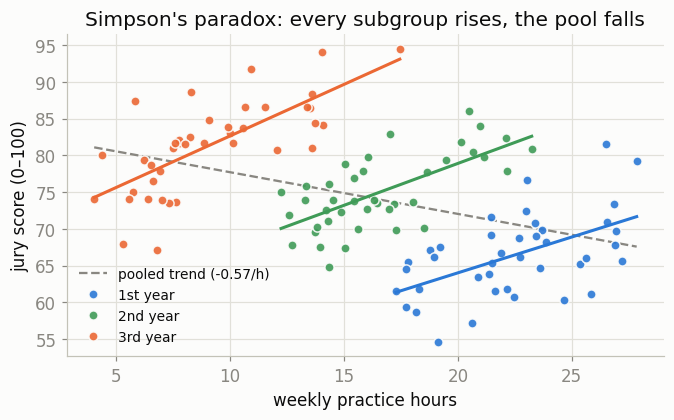

In [12]:
# ---------- plot: every cohort rises while the pool falls ----------
fig, ax = plt.subplots(figsize=(7, 3.8))

# the pooled line, dashed, for contrast
xs = np.array([practice.min(), practice.max()])
ax.plot(xs, slope_pooled * xs + int_pooled, color=MUTED, linewidth=1.5,
        linestyle="--", label=f"pooled trend ({slope_pooled:+.2f}/h)")

# each cohort: its own points and its own rising trend line
for name, _, _, color in cohorts:
    mask = year == name
    ax.plot(practice[mask], score[mask], "o", color=color, markersize=6,
            markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.9, label=name)
    s, i = cohort_fits[name]
    xr = np.array([practice[mask].min(), practice[mask].max()])
    ax.plot(xr, s * xr + i, color=color, linewidth=2)

ax.set_xlabel("weekly practice hours")
ax.set_ylabel("jury score (0–100)")
ax.set_title("Simpson's paradox: every subgroup rises, the pool falls")
ax.legend(frameon=False, fontsize=9)
plt.show()

**What happened.** Year level is associated with *both* variables: senior students
practice fewer hours *and* score higher. Pooling the cohorts lets that between-group
pattern (down-and-to-the-right) overwhelm the within-group pattern (up-and-to-the-
right). Both trends are arithmetically true — they answer *different questions*:

- *"Do students who practice more score higher?"* — No (pooled), because heavy
  practicers are mostly first-years.
- *"If a given student practices more, will they score higher?"* — Yes (+1.2 points
  per hour, within every cohort). This is the causal question, and the pooled plot
  answers it wrongly.

This is not a textbook curiosity. The most famous real case is the 1973 UC Berkeley
graduate admissions data: pooled figures suggested women were admitted at a lower
rate, yet within most individual departments women's admission rates were *equal or
higher* — women had applied disproportionately to the most competitive departments.

**The question to ask of any aggregate trend: "compared within what?"** — and note
the trap cuts both ways: just as pooling can hide subgroup truth, hunting through
subgroups until one shows the trend you want is how false findings get manufactured.

## 3. Regression to the mean — the difficult second album

Final trap. It is a music-industry proverb that a breakthrough debut is followed by
a disappointing second album — the *sophomore slump*. Here is a world where the
proverb is guaranteed to come true, for a reason that has nothing to do with
label pressure, touring fatigue or creative burnout.

An album's first-month streams, like every measurement in this course, are

$$\text{streams} = \text{quality of the band} + \text{release luck}$$

— a playlist placement, a clip that goes viral, a slow news week. Our simulated
scene has **100 new bands**; quality averages 250 thousand streams' worth, and
release luck swings results by about ±90 thousand either way.

After the debut albums come out, two things happen:

- the **20 biggest debuts** are signed by major labels;
- the **20 weakest debuts** fire their managers in frustration.

In our simulated world **neither event changes anything**: second-album streams are
the same band qualities with fresh luck. Watch what happens anyway.

In [13]:
# ---------- data: 100 bands, two albums each ----------
n_bands = 100

# Band quality, measured in the thousands of streams it is "worth".
# Quality is FIXED — the same on both albums. (.clip stops absurd negatives.)
quality = rng.normal(250, 80, n_bands).clip(min=20)

# Each album's streams = quality + fresh release luck (sd 90k).
# Same `quality` in both lines; only the luck is drawn anew.
debut  = (quality + rng.normal(0, 90, n_bands)).clip(min=5)
second = (quality + rng.normal(0, 90, n_bands)).clip(min=5)

# Select the extremes ON THE DEBUT NUMBERS — this selection is the whole trick.
# np.argsort gives band indices ordered from weakest debut to biggest.
order = np.argsort(debut)
flops, hits = order[:20], order[-20:]

# ---------- analysis: what each group's numbers look like ----------
print("Top 20 debuts (signed by major labels):")
print(f"  debut album mean:  {debut[hits].mean():5.0f}k streams")
print(f"  second album mean: {second[hits].mean():5.0f}k streams   "
      f"→ 'sophomore slump' of {second[hits].mean() - debut[hits].mean():+.0f}k")
print("\nBottom 20 debuts (fired their manager):")
print(f"  debut album mean:  {debut[flops].mean():5.0f}k streams")
print(f"  second album mean: {second[flops].mean():5.0f}k streams   "
      f"→ 'comeback' of {second[flops].mean() - debut[flops].mean():+.0f}k")
print(f"\nWhole roster, both albums: {debut.mean():.0f}k → {second.mean():.0f}k "
      "(nothing changed, as designed)")

Top 20 debuts (signed by major labels):
  debut album mean:    435k streams
  second album mean:   331k streams   → 'sophomore slump' of -104k

Bottom 20 debuts (fired their manager):
  debut album mean:     75k streams
  second album mean:   229k streams   → 'comeback' of +154k

Whole roster, both albums: 252k → 263k (nothing changed, as designed)


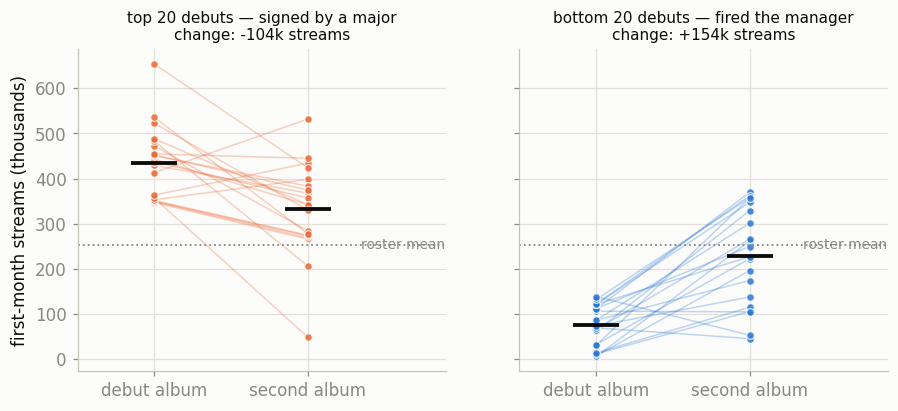

In [14]:
# ---------- plot: debut vs second album for both extreme groups ----------
def draw_release(second_now, note=""):
    """Draw the two before/after panels (top-20 debuts left, bottom-20 right).

    Takes the second-album streams as an argument so the button further down
    can redraw the same picture with freshly drawn luck.
    """
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), sharey=True)
    groups = [(axes[0], hits, ORANGE, "top 20 debuts — signed by a major"),
              (axes[1], flops, BLUE, "bottom 20 debuts — fired the manager")]
    for ax, idx, color, label in groups:
        # one line per band, connecting its debut streams to its second-album streams
        for i in idx:
            ax.plot([0, 1], [debut[i], second_now[i]], color=color, alpha=0.3,
                    linewidth=1)
            ax.plot([0, 1], [debut[i], second_now[i]], "o", color=color, markersize=5,
                    markeredgecolor=SURFACE, markeredgewidth=0.8, alpha=0.85)
        # thick black ticks: the group means before and after
        m1, m2 = debut[idx].mean(), second_now[idx].mean()
        ax.hlines(m1, -0.15, 0.15, color=INK, linewidth=2.5)
        ax.hlines(m2, 0.85, 1.15, color=INK, linewidth=2.5)
        # dotted line: the all-roster mean the groups drift back toward
        ax.axhline(debut.mean(), color=MUTED, linewidth=1.2, linestyle=":")
        ax.annotate("roster mean", (1.35, debut.mean()), color=MUTED, fontsize=9,
                    va="center")
        ax.set_xticks([0, 1], ["debut album", "second album"])
        ax.set_xlim(-0.5, 1.9)
        ax.set_title(f"{label}\nchange: {m2 - m1:+.0f}k streams{note}", fontsize=10)
    axes[0].set_ylabel("first-month streams (thousands)")
    plt.show()
    plt.close(fig)   # tidy up when called from a button callback

draw_release(second)

Nothing about the bands changed, yet the signed stars slumped by tens of thousands
of streams — and the fire-your-manager bands staged a comeback. The music press has
its headlines ready:

> *"Major-label pressure destroys creativity"* — and — *"Sacking your manager pays off."*

Both conclusions are pure artefact.

**Why it must happen.** The top 20 were selected *because* their debuts were
extreme — and an extremely big debut usually combines high quality with **good
release luck**. Quality carries over to the second album; the luck does not. Fresh,
average luck drags their streams back down toward the roster mean (dotted line) —
hence the name, *regression to the mean*. The mirror image lifts the bottom 20,
whose debut numbers were partly *bad* luck.

Click below to release another round of second albums with fresh luck — the slump
and the comeback both appear every single time, though nothing ever changes.

In [15]:
# ---------- interactive: re-release the second albums with fresh luck ----------
release_rng = np.random.default_rng(99)   # separate generator, fresh luck per click
release = {"k": 0}                        # how many rounds we have run
release_button = widgets.Button(description="🎵  release another second album",
                                layout=widgets.Layout(width="260px"))
release_panel = widgets.Output()

def rerun_release(_):
    release["k"] += 1
    # same band qualities as above — ONLY the release luck is new
    second_new = (quality + release_rng.normal(0, 90, n_bands)).clip(min=5)
    slump = second_new[hits].mean() - debut[hits].mean()
    with release_panel:
        release_panel.clear_output(wait=True)
        print(f"Round #{release['k']}: the 'sophomore slump' struck again — "
              f"{slump:+.0f}k streams for the signed bands")
        draw_release(second_new, note=f"   (round #{release['k']})")

release_button.on_click(rerun_release)
display(widgets.VBox([release_button, release_panel]))

Regression to the mean stalks every corner of research and everyday judgement:

- The bottom scorers of a jury "improve" after a remedial masterclass — whether or
  not the masterclass taught anything.
- Patients see the doctor when symptoms peak — and credit whatever they took next.
- A harsh review is followed by a better performance, a rave by a worse one — which
  quietly teaches critics that harshness "works" and praise "backfires"
  (psychologist Daniel Kahneman first spotted exactly this among flight instructors).

**The antidote is a comparison group.** Compare the signed bands with equally
successful debut bands who stayed independent: both groups would slump by about the
same amount, and the label's true effect (zero) would be exposed. Selection on
extreme results makes movement toward the mean a mathematical certainty; only a
comparison group can tell you how much of the change your intervention — or your
record deal — actually caused.

## 4. The moral: correct numbers, wrong conclusions

None of today's traps involved bad data. Every dataset was honestly collected and
every calculation was right — the failure was always in the *causal story* told
about the numbers.

| The trap | The seductive headline | What is really going on | The question to ask |
|---|---|---|---|
| Correlation ≠ causation | "Music training sharpens your hearing" | A confounder (a musical childhood) drives both variables — musicians are self-selected | *What third variable could produce this? Who was randomised?* |
| Simpson's paradox | "Practice lowers your scores" | A grouping variable reverses the pooled trend | *Compared within what? What happens inside each subgroup?* |
| Regression to the mean | "The second album always disappoints" | Extremes selected on luck drift back to average | *Where is the comparison group?* |

Notice the common thread: each trap is defeated by a **design** choice, not a
calculation — randomise the treatment, compare within subgroups, keep a control
group. Statistics can quantify uncertainty, but no formula rescues a study that
asked its question the wrong way. That is why research *methods* — not just
statistics — are the subject of this course.

**Things to try** (edit the code and re-run):

1. In Section 1, give training a *real* effect: add `+ 2 * training_years` to the
   `hearing_score` formula (and `+ 0.3 * assigned_hours` to `hearing_after`). Can
   you tell the difference from the observational scatter alone? What does the
   training study now show?
2. In Section 2, set the within-cohort effect to zero (change `TRUE_SLOPE` to `0`).
   What does the pooled plot claim now, and what is the truth?
3. In Section 3, make streaming success nearly luck-free: change both
   `rng.normal(0, 90, ...)` scales to `10`. How big is the sophomore slump now?
   What if luck swings by `200` instead?
4. Change the seed in the first code cell — different luck, same traps.